## Exercise E2
### Loading and Visualising Data from Flat Files
#### Tatjana Noah Steixner

In the following notebook, a ctd cast file with missing headers is modified to include descriptive headers, and saved to the current working directory as a standard .csv file.  
Temperature and salinity data from the ctd cast described is plotted as a 2-panel plot using matplotlib.  
Finally, adequately labelled data from an SA Agulhas II cruise in 2017 is run through a series of diagnostic plots and summarised, in order to gain a basic understanding of the data, and to determine whether average wind speed varies by latitude and temperature.  

In [2]:
#import necessary modules - pandas for data wrangling, numpy for mathematical operations, pyplot for plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

In [3]:
ctd_missing_header = pd.read_csv("./for_nitpicker.dat", sep="\t", header=None)

ctd_missing_header.columns = ["date", "time", "depth_m", "temp_degc", "salinity_psu"] #set colnames with appropriate units as specified in task
print(ctd_missing_header.head()) #check if renaming is successful

#write file to .csv in current dir, drop index, use default options for header and separator
#i.e. header = True and sep = ","
ctd_missing_header.to_csv("external_ctd_data_20081129.csv", index=False)

         date   time  depth_m  temp_degc  salinity_psu
0  11/29/2008  06:52        5      28.97         35.21
1  11/29/2008  06:52        6      28.98         35.21
2  11/29/2008  06:52        7      28.99         35.21
3  11/29/2008  06:52        8      28.96         35.21
4  11/29/2008  06:52        9      28.99         35.21


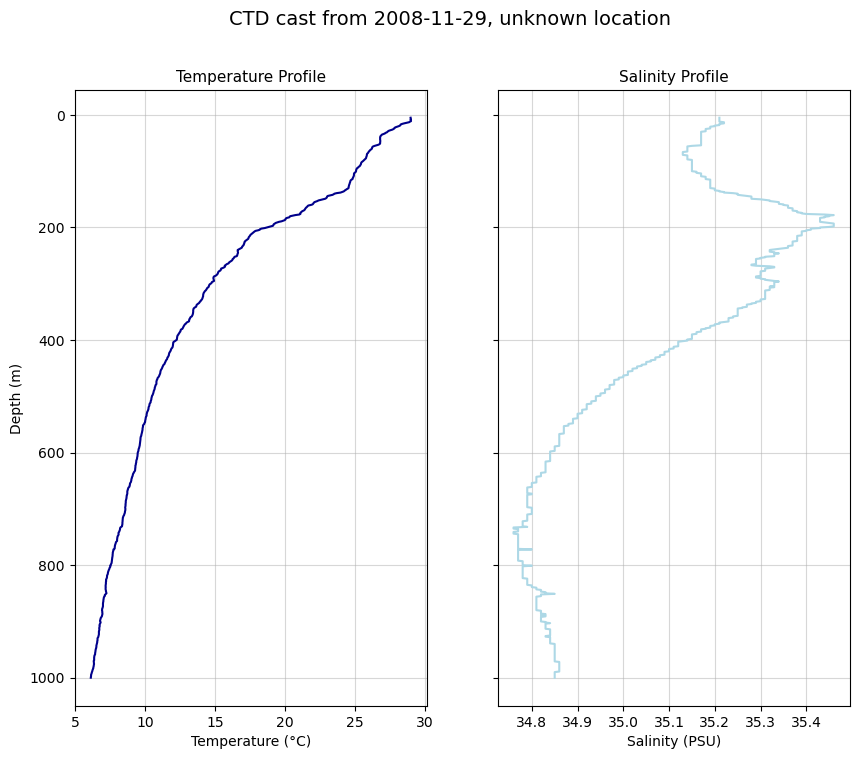

<Figure size 640x480 with 0 Axes>

In [4]:
#create 2-panel temperature and salinity plot with shared y-axis
#set style as appropriate
plt.style.use('seaborn-v0_8-colorblind')

#create 2 subplot panels with 1 row, 2 columns, share y-axis
fig, ax = plt.subplots(1, 2, figsize=(10, 8), sharey=True)
ax[0].plot(ctd_missing_header["temp_degc"], ctd_missing_header["depth_m"], color="darkblue") #plot temperature
ax[1].plot(ctd_missing_header["salinity_psu"], ctd_missing_header["depth_m"], color="lightblue") #plot salinity
plt.gca().invert_yaxis() #invert y axis so plot displays as depth profile 

#set labels, title and subtitles
ax[0].set_xlabel("Temperature (°C)", fontsize=10)
ax[1].set_xlabel("Salinity (PSU)", fontsize=10)
ax[0].set_ylabel("Depth (m)", fontsize=10)
ax[0].set_title("Temperature Profile", fontsize=11)
ax[1].set_title("Salinity Profile",fontsize=11)
ax[0].grid(True, alpha=0.5) 
ax[1].grid(True, alpha=0.5) 
fig.suptitle("CTD cast from 2008-11-29, unknown location", fontsize=14)

#show and save figure, medium resolution
plt.show()
plt.savefig("ctd_profile_20081129.png", dpi=150)

For the analysis of data from the SA Agulhas II winter cruise, the following AI prompt was used to generate code for the solution as specified in the task:  

''' Design the following:
(file is uploaded)

Import .csv file containing environmental variables taken throughout a cruise in the southern ocean in python
Use the appropriate column for the time index
Ensure missing values are properly recognized.

Ship reached the southernmost location on July 4th. Use time indexing to select the data from departure to that date included. 

Using selected data, plot time series of temperature with the appropriate labels. Save the figure using the 'grayscale' style.  

Plot a histogram of the salinity distribution using bins of 0.5 psu between 30 and 35.

Calculate the mean, standard deviation and the interquartile range for temperature and salinity and present the results in a table.

Create a scatter plot of wind speed and air temperature, encoding the latitude information in colour. Wind speed is in meters per second and air temperature in degrees Celsius. Save this figure in PNG with a resolution of 300 DPI. '''  

As many of the steps required were introduced previously, an AI-independent solution was started and compared to the AI-generated solution.  
Code adapted from AI output is indicated.  

In [5]:
#load data from SA Agulhas II winter cruise
#define NaN values to common defaults
saa2_wc_17 = pd.read_csv("./SAA2_WC_2017_metocean_10min_avg.csv", 
                         na_values=["NaN", "NA", ""])

print(saa2_wc_17.head(2))

#shows that TIME_SERVER column is datetime and should be parsed, set as index
saa2_wc_17["TIME_SERVER"] = pd.to_datetime(saa2_wc_17["TIME_SERVER"])
saa2_wc_17.set_index("TIME_SERVER", inplace=True)

#Diagnostic output, as suggested by AI-generated script
print(f"Shape: {saa2_wc_17.shape}") #dimensions of data
print(f"\nDate range: {saa2_wc_17.index[0]} - {saa2_wc_17.index[-1]}") #check date range
print(f"\nMissing values per column:\n{saa2_wc_17.isnull().sum()}") #summarise missing values per column
#AI analysis suggests that NAs are concurrent with a GPS fallout at the beginning of the cruise
#this is difficult to verify, but appears feasible, temperature and salinity column have 114 additional NAs

#in order to work meaningfully with coordinates, convert to decimal degrees
#function provided is extended to handle negative values (°S)
def nmea_to_decimal(lat_series, ns_series):
    deg = (lat_series // 100).astype(float)
    minutes = lat_series % 100
    decimal = deg + minutes / 60
    decimal[ns_series == 'S'] *= -1
    return decimal

saa2_wc_17['LAT_DD'] = nmea_to_decimal(saa2_wc_17['LATITUDE'], saa2_wc_17['N_S'])


     id       TIME_SERVER  TIME_GPS  LATITUDE N_S  LONGITUDE E_W  HUMIDITY  \
0  1256  2017/06/28 17:10  17:09:58  3428.595   S   1819.447   E      73.2   
1  1257  2017/06/28 17:20  17:19:58  3430.443   S   1820.241   E      65.2   

   BAROMETER  AIR_TEMPERATURE  WIND_SPEED_REL  WIND_SPEED_TRUE  WIND_DIR_REL  \
0     1.0175             12.5             6.7              5.9          20.8   
1     1.0174             12.7             6.3              7.7          31.8   

   WIND_DIR_TRUE    PAR  TSG_SALINITY  TSG_TEMP  
0          323.8  16.26           NaN       NaN  
1          310.6  16.26       34.3408    17.169  
Shape: (2202, 16)

Date range: 2017-06-28 17:10:00 - 2017-07-14 00:00:00

Missing values per column:
id                   0
TIME_GPS           225
LATITUDE           225
N_S                225
LONGITUDE          225
E_W                225
HUMIDITY           225
BAROMETER          225
AIR_TEMPERATURE    225
WIND_SPEED_REL     225
WIND_SPEED_TRUE    228
WIND_DIR_REL       2

In [6]:
#subset data as in AI generated script
#Southernmost point is reached on 4th of July, this is used as mask for filtering
cutoff = '2017-07-04'
saa2_wc_17_subset = saa2_wc_17.loc[:cutoff].copy()

#verify if successful by printing date range
print(f"Range: {saa2_wc_17_subset.index.min()} - {saa2_wc_17_subset.index.max()}")

Range: 2017-06-28 17:10:00 - 2017-07-04 23:50:00


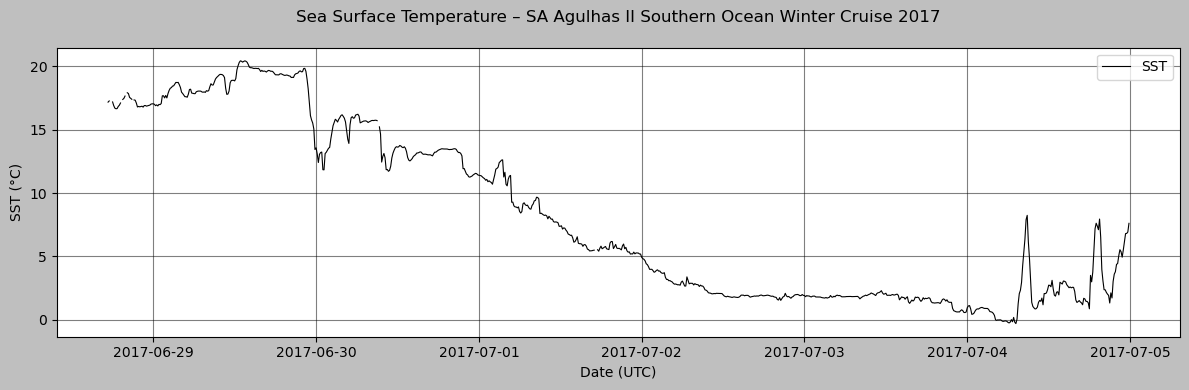

In [7]:
#Plot time series of data, as unspecified only SST is plotted
#Set style to grayscale
plt.style.use("grayscale")

#Figure adapted from AI output with changes in styling and labels
fig, ax = plt.subplots(figsize=(12, 4))
#plot SST data
ax.plot(saa2_wc_17_subset.index, saa2_wc_17_subset['TSG_TEMP'], linewidth=0.8, label='SST')
#set axes labels and title
ax.set_xlabel("Date (UTC)")
ax.set_ylabel("SST (°C)")
ax.set_title("Sea Surface Temperature – SA Agulhas II Southern Ocean Winter Cruise 2017\n",fontsize=12)
ax.grid(True, alpha=0.5) #set gird
ax.legend(fontsize=10) #add legend
plt.tight_layout() #formatting
plt.show()
plt.savefig('saa2_wc_17_sst_timeseries.png', dpi=150) #save figure
plt.close()


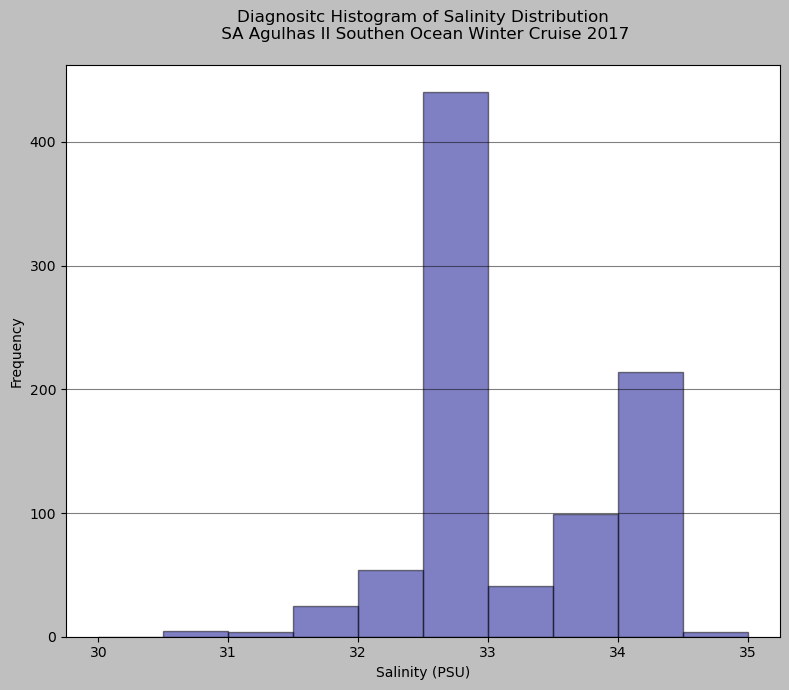

In [8]:
#Diagnostic histogram of salinity distribution throughout cruise
#creat 0.5 psu bins in range 30-35 using np.arange
bins = np.arange(30, 35 + 0.5, 0.5)

#histogram adapted from AI output: 
fig, ax = plt.subplots(figsize=(8,7))
ax.hist(saa2_wc_17_subset["TSG_SALINITY"].dropna(), bins=bins, 
        color="darkblue", alpha=0.5, edgecolor="k") #plot salinity data binned in pre-defined bins
ax.set_xlabel("Salinity (PSU)")
ax.set_ylabel("Frequency")
ax.set_title("Diagnositc Histogram of Salinity Distribution\n SA Agulhas II Southen Ocean Winter Cruise 2017\n")
ax.grid(axis="y",alpha=0.5)
plt.tight_layout()
plt.show()
fig.savefig("saa_wc_17_salinity_hist.png", dpi=150)
plt.close()

                   Mean  Std Dev      IQR
Variable                                 
SST (°C)         8.1465   6.7480  11.7688
Salinity (PSU)  33.1106   1.1402   1.2726


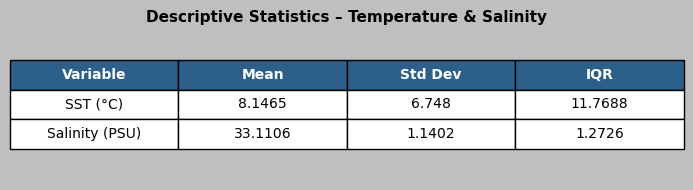

In [9]:
#Summary statistics of temperature and salinity data
#Follows AI-generated approach to render table

#define convenience function for iqr calculation
def iqr(series):
    return series.quantile(0.75) - series.quantile(0.25)

#create df from dict for each statistic
stats = pd.DataFrame({
    'Variable': ['SST (°C)', 'Salinity (PSU)'],
    'Mean':  [saa2_wc_17_subset['TSG_TEMP'].mean(), saa2_wc_17_subset['TSG_SALINITY'].mean()],
    'Std Dev': [saa2_wc_17_subset['TSG_TEMP'].std(), saa2_wc_17_subset['TSG_SALINITY'].std()],
    'IQR':   [iqr(saa2_wc_17_subset['TSG_TEMP']), iqr(saa2_wc_17_subset['TSG_SALINITY'])]
})

#set index for table generation
stats = stats.set_index('Variable').round(4)
#print output
print(stats.to_string())

#create cleanly rendered figure/table
fig, ax = plt.subplots(figsize=(7, 2))
ax.axis('off')
tbl = ax.table(cellText=stats.reset_index().values,
    colLabels=['Variable', 'Mean', 'Std Dev', 'IQR'],
    cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
#header row
for j in range(4):
    tbl[0, j].set_facecolor('#2c5f8a')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
plt.title('Descriptive Statistics – Temperature & Salinity', fontsize=11,
          pad=5, fontweight='bold')
plt.tight_layout()
plt.show()
plt.savefig('saa2_wc_17_temp_salinity_stats.png', dpi=150, bbox_inches='tight')
plt.close()

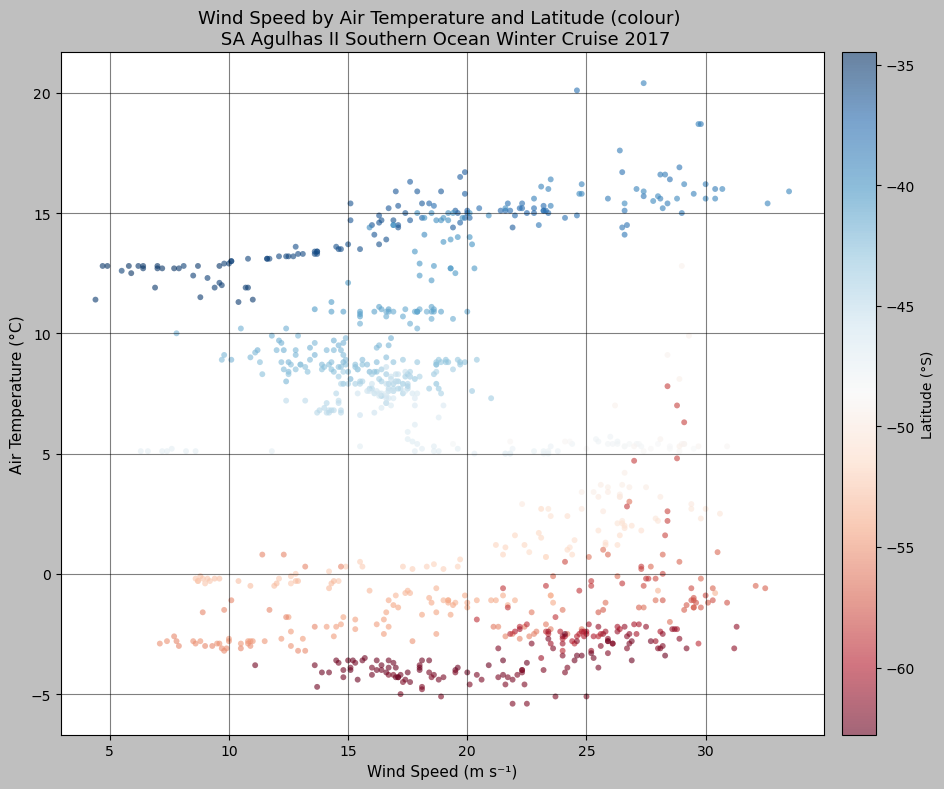

In [10]:
#Plot of windspeed by temperature and latitude

#create new df for scatter plotting
#drop NAs from wind speed, air temp and latitude columns 
scatter_df = saa2_wc_17_subset[['WIND_SPEED_TRUE', 'AIR_TEMPERATURE', 'LAT_DD']].dropna()

#initiate figure, set size
fig, ax = plt.subplots(figsize=(10, 8))
#plot wind speed/air temp and set colour by latitude
sc = ax.scatter(scatter_df['WIND_SPEED_TRUE'], scatter_df['AIR_TEMPERATURE'],
    c=scatter_df['LAT_DD'], cmap="RdBu",alpha=0.6,s=18,linewidths=0)
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Latitude (°S)")
ax.set_xlabel("Wind Speed (m s⁻¹)", fontsize=11)
ax.set_ylabel("Air Temperature (°C)", fontsize=11)
ax.set_title("Wind Speed by Air Temperature and Latitude (colour) \n SA Agulhas II Southern Ocean Winter Cruise 2017", fontsize=13)
ax.grid(alpha=0.5)
plt.tight_layout()
plt.show()
plt.savefig("saa2_wc_17_airtemp_wind_scatter.png", dpi=300)
plt.close()

The plot indicates that while air temperatures drop notably at lower latitudes, generally ranging from 5°C to -5°C, wind speeds are not obviously correlated to changes in latidtude. The given data indicates that if anything, there is a higher range of wind speeds to be expected at higher latitudes, with the most stable windspeeds (ranging from 10-20 m/s) observed between 45°S and 50°S. Average wind speeds appear to increase at lower latitudes, with more frequent occurences of wind speeds ranging from 25-30 m/s below 55°S, but similar wind speeds were observed at higher latitudes as well, and the maximum windspeed of 33.5 m/S observed at 42°S.  

### Bibliography


Anthropic. 2026. "Southern Ocean Cruise Metocean Data Analysis." AI-generated output. Claude Sonnet 4.6. Accessed May 7, 2026. https://claude.ai. 
 
Hunter, J. D. “Matplotlib: A 2D Graphics Environment.” Computing in Science & Engineering 9, no. 3 (2007): 90–95. https://doi.org/10.1109/MCSE.2007.55.  
